In [1]:
# Cell 1: Environment Setup, Repository Cloning, & Library Imports

!pip install -q sentence-transformers

import os
if not os.path.exists('/content/ESC'):
    os.system('git clone https://github.com/Yiwei98/ESC.git')

os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

import json
import re
import random
import time
import requests
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer, util
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model_embedder = SentenceTransformer('all-mpnet-base-v2', device=device)
print("Encoder loaded ✅")

Working directory: /content/ESC
Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder loaded ✅


In [2]:
# Cell 2: Helper Functions & Text Processing

ANS_RE = re.compile(r"#### (\-?[0-9\.\,]+)")
INVALID_ANS = "[invalid]"

def extract_gold_answer(completion):
    match = ANS_RE.search(completion)
    if match:
        return str(match.group(1).strip().replace(",", ""))
    return INVALID_ANS

def extract_predicted_number(text):
    number_list = re.findall(r"\d+\.?\d*", text)
    try:
        return str(number_list[-1].strip('.'))
    except IndexError:
        return "-1000"

def extract_gold_answer_strategy(answer):
    if isinstance(answer, dict):
        return 'yes' if answer.get('Yes', 0) == 1 else 'no'
    s = str(answer).lower()
    return 'yes' if "'yes': 1" in s or '"yes": 1' in s else 'no'

def extract_predicted_strategy(text):
    text = str(text).lower().strip()
    for sent in reversed(text.split('.')):
        sent = sent.strip()
        if sent.endswith('yes') or ' yes' in sent[-15:] or sent.startswith('yes'):
            return 'yes'
        if sent.endswith('no') or ' no' in sent[-15:] or sent.startswith('no'):
            return 'no'
    if 'yes' in text: return 'yes'
    if 'no'  in text: return 'no'
    return '[invalid]'

def extract_final_answer(text, task_type):
    if task_type == 'gsm8k':
        return extract_predicted_number(text)
    else:
        return extract_predicted_strategy(text)

def calculate_similarity_from_embeddings(all_embeddings, start, end):
    window_emb = all_embeddings[start:end]
    if len(window_emb) <= 1:
        return 1.0
    sim_matrix   = util.cos_sim(window_emb, window_emb).cpu().numpy()
    triu_indices = np.triu_indices_from(sim_matrix, k=1)
    return float(np.mean(sim_matrix[triu_indices]))

In [ ]:
# API Setup — NVIDIA GPT-OSS-20B (OpenAI Client)

!pip install -q openai

from openai import OpenAI

nvidia_client = OpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key  = "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"
)

def call_gptoss(prompt):
    for attempt in range(3):
        try:
            completion = nvidia_client.chat.completions.create(
                model       = "openai/gpt-oss-20b",
                messages    = [{"role": "user", "content": prompt}],
                temperature = 0.7,
                max_tokens  = 128,
                stream      = False
            )
            text = completion.choices[0].message.content
            if not text:
                text = getattr(completion.choices[0].message, "reasoning_content", None)
            if text:
                return text.strip()
            return None
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            time.sleep(10)
    return None

# Test
import time
start = time.time()
test  = call_gptoss("What is 2+2?")
print(f"Response: {test}")
print(f"Time: {time.time()-start:.1f}s ✅")

Response: 2 + 2 = 4.
Time: 2.3s ✅


In [ ]:
# Generate GPT-OSS-20B — GSM8K (Fresh Start + Parallel)

import os, json, shutil, time
import concurrent.futures
from tqdm.notebook import tqdm
from google.colab import drive
from openai import OpenAI

# ── Working directory ─────────────────────────────────────────────────────────
os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

# ── NVIDIA API ────────────────────────────────────────────────────────────────
nvidia_client = OpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key  = "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"
)

def call_gptoss(prompt):
    for attempt in range(5):
        try:
            completion = nvidia_client.chat.completions.create(
                model       = "openai/gpt-oss-20b",
                messages    = [{"role": "user", "content": prompt}],
                temperature = 0.7,
                max_tokens  = 128,
                stream      = False
            )
            text = completion.choices[0].message.content
            if not text:
                text = getattr(completion.choices[0].message, "reasoning_content", None)
            if text:
                return text.strip()
            return None
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            wait = (attempt + 1) * 10
            time.sleep(wait)
    return None

# ── Mount Drive ───────────────────────────────────────────────────────────────
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
os.makedirs("/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k", exist_ok=True)
print("Drive mounted ✅")

# ── Setup paths ───────────────────────────────────────────────────────────────
TASK_TYPE   = "gsm8k"
output_path = f"GPT-OSS-20B_result/{TASK_TYPE}/T0.7.jsonl"
drive_path  = "/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k/T0.7.jsonl"
source_path = f"GPT3.5_result/{TASK_TYPE}/T0.7.jsonl"

os.makedirs(f"GPT-OSS-20B_result/{TASK_TYPE}", exist_ok=True)

# ── Delete old files to start fresh ──────────────────────────────────────────
if os.path.exists(output_path):
    os.remove(output_path)
    print("Old local file deleted ✅")
if os.path.exists(drive_path):
    os.remove(drive_path)
    print("Old Drive file deleted ✅")

# ── Load source data ──────────────────────────────────────────────────────────
with open(source_path) as f:
    source_data = f.readlines()[50:100]

print("Starting fresh — 50 questions")

# ── Parallel API calls ────────────────────────────────────────────────────────
def call_single(args):
    prompt, idx = args
    time.sleep(idx * 0.5)
    result = call_gptoss(prompt)
    return result if result else ""

def generate_40_parallel(prompt):
    args = [(prompt, i) for i in range(40)]
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(call_single, args))
    return results

# ── Generation Loop ───────────────────────────────────────────────────────────
total_start = time.time()

with open(output_path, "a") as out_f:  # ← "w" fresh write
    for idx, line in enumerate(tqdm(source_data, desc="GPT-OSS / gsm8k")):
        q_start  = time.time()
        tem      = json.loads(line)
        question = tem.get('question', tem.get('input', ''))
        answer   = tem['answer']
        prompt   = f"Solve step by step:\n{question}\nLet's think step by step:"

        generated = generate_40_parallel(prompt)

        out_f.write(json.dumps({
            "question":         question,
            "answer":           answer,
            "generated_answer": generated
        }) + "\n")
        out_f.flush()

        actual_idx = idx + 1
        q_time     = (time.time() - q_start) / 60
        elapsed    = (time.time() - total_start) / 60
        eta        = (50 - actual_idx) * q_time

        if actual_idx % 10 == 0:
            shutil.copy(output_path, drive_path)
            print(f"Saved {actual_idx}/50 ✅ | Elapsed: {elapsed:.1f} min | ETA: {eta:.1f} min")

# ── Final Backup ──────────────────────────────────────────────────────────────
shutil.copy(output_path, drive_path)
total_time = (time.time() - total_start) / 60
print(f"\n✅ GSM8K done! Total time: {total_time:.1f} min — Final backup saved to Drive.")

Working directory: /content/ESC
Mounted at /content/drive
Drive mounted ✅
Old local file deleted ✅
Old Drive file deleted ✅
Starting fresh — 50 questions


GPT-OSS / gsm8k:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Generate GPT-OSS-20B — GSM8K (Next 50: questions 51-100)

import os, json, shutil, time
import concurrent.futures
from tqdm.notebook import tqdm
from google.colab import drive
from openai import OpenAI

os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

nvidia_client = OpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key  = "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"
)

def call_gptoss(prompt):
    for attempt in range(5):
        try:
            completion = nvidia_client.chat.completions.create(
                model       = "openai/gpt-oss-20b",
                messages    = [{"role": "user", "content": prompt}],
                temperature = 0.7,
                max_tokens  = 128,
                stream      = False
            )
            text = completion.choices[0].message.content
            if not text:
                text = getattr(completion.choices[0].message, "reasoning_content", None)
            if text:
                return text.strip()
            return None
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            wait = (attempt + 1) * 10
            time.sleep(wait)
    return None

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
os.makedirs("/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k", exist_ok=True)
print("Drive mounted ✅")

TASK_TYPE   = "gsm8k"
output_path = f"GPT-OSS-20B_result/{TASK_TYPE}/T0.7.jsonl"
drive_path  = "/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k/T0.7.jsonl"
source_path = f"GPT3.5_result/{TASK_TYPE}/T0.7.jsonl"

with open(source_path) as f:
    source_data = f.readlines()[50:100]  # ← next 50

print(f"Generating questions 51-100")

def call_single(args):
    prompt, idx = args
    time.sleep(idx * 0.5)
    result = call_gptoss(prompt)
    return result if result else ""

def generate_40_parallel(prompt):
    args = [(prompt, i) for i in range(40)]
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(call_single, args))
    return results

total_start = time.time()

with open(output_path, "a") as out_f:  # ← append mode
    for idx, line in enumerate(tqdm(source_data, desc="GPT-OSS / gsm8k")):
        q_start  = time.time()
        tem      = json.loads(line)
        question = tem.get('question', tem.get('input', ''))
        answer   = tem['answer']
        prompt   = f"Solve step by step:\n{question}\nLet's think step by step:"

        generated = generate_40_parallel(prompt)

        out_f.write(json.dumps({
            "question":         question,
            "answer":           answer,
            "generated_answer": generated
        }) + "\n")
        out_f.flush()

        actual_idx = 50 + idx + 1
        q_time     = (time.time() - q_start) / 60
        elapsed    = (time.time() - total_start) / 60
        eta        = (100 - actual_idx) * q_time

        if actual_idx % 10 == 0:
            shutil.copy(output_path, drive_path)
            print(f"Saved {actual_idx}/100 ✅ | Elapsed: {elapsed:.1f} min | ETA: {eta:.1f} min")

shutil.copy(output_path, drive_path)
total_time = (time.time() - total_start) / 60
print(f"\n✅ GSM8K 51-100 done! Total time: {total_time:.1f} min — Final backup saved to Drive.")

Working directory: /content/ESC
Mounted at /content/drive
Drive mounted ✅
Generating questions 51-100


GPT-OSS / gsm8k:   0%|          | 0/50 [00:00<?, ?it/s]

Saved 60/100 ✅ | Elapsed: 18.6 min | ETA: 81.7 min
Saved 70/100 ✅ | Elapsed: 41.7 min | ETA: 62.7 min
Saved 80/100 ✅ | Elapsed: 77.0 min | ETA: 47.0 min
Saved 90/100 ✅ | Elapsed: 113.5 min | ETA: 54.2 min
Saved 100/100 ✅ | Elapsed: 129.7 min | ETA: 0.0 min

✅ GSM8K 51-100 done! Total time: 129.7 min — Final backup saved to Drive.


In [ ]:
# Generate GPT-OSS-20B — Strategy (100 questions + Parallel)

import os, json, shutil, time
import concurrent.futures
from tqdm.notebook import tqdm
from google.colab import drive
from openai import OpenAI

os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

nvidia_client = OpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key  = "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"
)

def call_gptoss(prompt):
    for attempt in range(5):
        try:
            completion = nvidia_client.chat.completions.create(
                model       = "openai/gpt-oss-20b",
                messages    = [{"role": "user", "content": prompt}],
                temperature = 0.7,
                max_tokens  = 128,
                stream      = False
            )
            text = completion.choices[0].message.content
            if not text:
                text = getattr(completion.choices[0].message, "reasoning_content", None)
            if text:
                return text.strip()
            return None
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            wait = (attempt + 1) * 10
            time.sleep(wait)
    return None

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
os.makedirs("/content/drive/MyDrive/GPT-OSS-20B_result/strategy", exist_ok=True)
print("Drive mounted ✅")

TASK_TYPE   = "strategy"
output_path = f"GPT-OSS-20B_result/{TASK_TYPE}/T0.7.jsonl"
drive_path  = "/content/drive/MyDrive/GPT-OSS-20B_result/strategy/T0.7.jsonl"
source_path = f"GPT3.5_result/{TASK_TYPE}/T0.7.jsonl"

os.makedirs(f"GPT-OSS-20B_result/{TASK_TYPE}", exist_ok=True)

# ── Delete old files ──────────────────────────────────────────────────────────
if os.path.exists(output_path):
    os.remove(output_path)
    print("Old local file deleted ✅")
if os.path.exists(drive_path):
    os.remove(drive_path)
    print("Old Drive file deleted ✅")

with open(source_path) as f:
    source_data = f.readlines()[:100]  # ← 100 questions

print("Starting fresh — 100 questions")

def call_single(args):
    prompt, idx = args
    time.sleep(idx * 0.5)
    result = call_gptoss(prompt)
    return result if result else ""

def generate_40_parallel(prompt):
    args = [(prompt, i) for i in range(40)]
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(call_single, args))
    return results

total_start = time.time()

with open(output_path, "w") as out_f:
    for idx, line in enumerate(tqdm(source_data, desc="GPT-OSS / strategy")):
        q_start  = time.time()
        tem      = json.loads(line)
        question = tem.get('question', tem.get('input', ''))
        answer   = tem['answer']
        prompt   = f"Answer yes or no and explain:\n{question}\nLet's think step by step:"

        generated = generate_40_parallel(prompt)

        out_f.write(json.dumps({
            "question":         question,
            "answer":           answer,
            "generated_answer": generated
        }) + "\n")
        out_f.flush()

        actual_idx = idx + 1
        q_time     = (time.time() - q_start) / 60
        elapsed    = (time.time() - total_start) / 60
        eta        = (100 - actual_idx) * q_time

        if actual_idx % 10 == 0:
            shutil.copy(output_path, drive_path)
            print(f"Saved {actual_idx}/100 ✅ | Elapsed: {elapsed:.1f} min | ETA: {eta:.1f} min")

shutil.copy(output_path, drive_path)
total_time = (time.time() - total_start) / 60
print(f"\n✅ Strategy done! Total time: {total_time:.1f} min — Final backup saved to Drive.")

Working directory: /content/ESC
Mounted at /content/drive
Drive mounted ✅
Starting fresh — 100 questions


GPT-OSS / strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 10/100 ✅ | Elapsed: 9.9 min | ETA: 85.2 min
Saved 20/100 ✅ | Elapsed: 20.0 min | ETA: 74.5 min
Saved 30/100 ✅ | Elapsed: 29.9 min | ETA: 73.6 min
Saved 40/100 ✅ | Elapsed: 39.3 min | ETA: 54.6 min
Saved 50/100 ✅ | Elapsed: 49.8 min | ETA: 64.8 min
Saved 60/100 ✅ | Elapsed: 84.1 min | ETA: 40.1 min
Saved 70/100 ✅ | Elapsed: 96.1 min | ETA: 29.0 min
Saved 80/100 ✅ | Elapsed: 108.6 min | ETA: 20.3 min
Attempt 1 failed: Error code: 504
Saved 90/100 ✅ | Elapsed: 146.3 min | ETA: 10.0 min
Saved 100/100 ✅ | Elapsed: 157.5 min | ETA: 0.0 min

✅ Strategy done! Total time: 157.5 min — Final backup saved to Drive.


In [ ]:
# Generate GPT-OSS-20B — Strategy (Questions 151-200)

import os, json, shutil, time
import concurrent.futures
from tqdm.notebook import tqdm
from google.colab import drive
from openai import OpenAI

os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

nvidia_client = OpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key  = "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"
)

def call_gptoss(prompt):
    for attempt in range(5):
        try:
            completion = nvidia_client.chat.completions.create(
                model       = "openai/gpt-oss-20b",
                messages    = [{"role": "user", "content": prompt}],
                temperature = 0.7,
                max_tokens  = 128,
                stream      = False
            )
            text = completion.choices[0].message.content
            if not text:
                text = getattr(completion.choices[0].message, "reasoning_content", None)
            if text:
                return text.strip()
            return None
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            wait = (attempt + 1) * 10
            time.sleep(wait)
    return None

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
os.makedirs("/content/drive/MyDrive/GPT-OSS-20B_result/strategy", exist_ok=True)
print("Drive mounted ✅")

TASK_TYPE   = "strategy"
output_path = f"GPT-OSS-20B_result/{TASK_TYPE}/T0.7.jsonl"
drive_path  = "/content/drive/MyDrive/GPT-OSS-20B_result/strategy/T0.7.jsonl"
source_path = f"GPT3.5_result/{TASK_TYPE}/T0.7.jsonl"

os.makedirs(f"GPT-OSS-20B_result/{TASK_TYPE}", exist_ok=True)

# ── Restore from Drive ────────────────────────────────────────────────────────
shutil.copy(drive_path, output_path)
with open(output_path) as f:
    already_done = len(f.readlines())
print(f"Restored {already_done} questions from Drive ✅")

# ── Load remaining questions ──────────────────────────────────────────────────
with open(source_path) as f:
    source_data = f.readlines()[150:200]  # ← last 50

print(f"Generating questions 151-200")

def call_single(args):
    prompt, idx = args
    time.sleep(idx * 0.5)
    result = call_gptoss(prompt)
    return result if result else ""

def generate_40_parallel(prompt):
    args = [(prompt, i) for i in range(40)]
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(call_single, args))
    return results

total_start = time.time()

with open(output_path, "a") as out_f:  # ← append
    for idx, line in enumerate(tqdm(source_data, desc="GPT-OSS / strategy")):
        q_start  = time.time()
        tem      = json.loads(line)
        question = tem.get('question', tem.get('input', ''))
        answer   = tem['answer']
        prompt   = f"Answer yes or no and explain:\n{question}\nLet's think step by step:"

        generated = generate_40_parallel(prompt)

        out_f.write(json.dumps({
            "question":         question,
            "answer":           answer,
            "generated_answer": generated
        }) + "\n")
        out_f.flush()

        actual_idx = 150 + idx + 1
        q_time     = (time.time() - q_start) / 60
        elapsed    = (time.time() - total_start) / 60
        eta        = (200 - actual_idx) * q_time

        if actual_idx % 10 == 0:
            shutil.copy(output_path, drive_path)
            print(f"Saved {actual_idx}/200 ✅ | Elapsed: {elapsed:.1f} min | ETA: {eta:.1f} min")

shutil.copy(output_path, drive_path)
total_time = (time.time() - total_start) / 60
print(f"\n✅ Strategy done! Total time: {total_time:.1f} min — Final backup saved to Drive.")

Working directory: /content/ESC
Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Drive mounted ✅
Restored 150 questions from Drive ✅
Generating questions 151-200


GPT-OSS / strategy:   0%|          | 0/50 [00:00<?, ?it/s]

Saved 160/200 ✅ | Elapsed: 23.6 min | ETA: 255.0 min
Saved 170/200 ✅ | Elapsed: 77.2 min | ETA: 199.1 min
Saved 180/200 ✅ | Elapsed: 135.8 min | ETA: 32.3 min
Saved 190/200 ✅ | Elapsed: 177.6 min | ETA: 19.7 min
Saved 200/200 ✅ | Elapsed: 200.4 min | ETA: 0.0 min

✅ Strategy done! Total time: 200.4 min — Final backup saved to Drive.


In [ ]:
# Generate GPT-OSS-20B — GSM8K (Questions 101-200)

import os, json, shutil, time
import concurrent.futures
from tqdm.notebook import tqdm
from google.colab import drive
from openai import OpenAI

os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

nvidia_client = OpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key  = "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"
)

def call_gptoss(prompt):
    for attempt in range(5):
        try:
            completion = nvidia_client.chat.completions.create(
                model       = "openai/gpt-oss-20b",
                messages    = [{"role": "user", "content": prompt}],
                temperature = 0.7,
                max_tokens  = 128,
                stream      = False
            )
            text = completion.choices[0].message.content
            if not text:
                text = getattr(completion.choices[0].message, "reasoning_content", None)
            if text:
                return text.strip()
            return None
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            wait = (attempt + 1) * 10
            time.sleep(wait)
    return None

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
os.makedirs("/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k", exist_ok=True)
print("Drive mounted ✅")

TASK_TYPE   = "gsm8k"
output_path = f"GPT-OSS-20B_result/{TASK_TYPE}/T0.7.jsonl"
drive_path  = "/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k/T0.7.jsonl"
source_path = f"GPT3.5_result/{TASK_TYPE}/T0.7.jsonl"

os.makedirs(f"GPT-OSS-20B_result/{TASK_TYPE}", exist_ok=True)

# ── Restore from Drive ────────────────────────────────────────────────────────
shutil.copy(drive_path, output_path)
with open(output_path) as f:
    already_done = len(f.readlines())
print(f"Restored {already_done} questions from Drive ✅")

# ── Load remaining questions ──────────────────────────────────────────────────
with open(source_path) as f:
    source_data = f.readlines()[100:200]  # ← questions 101-200

print(f"Generating questions 101-200")

def call_single(args):
    prompt, idx = args
    time.sleep(idx * 0.5)
    result = call_gptoss(prompt)
    return result if result else ""

def generate_40_parallel(prompt):
    args = [(prompt, i) for i in range(40)]
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(call_single, args))
    return results

total_start = time.time()

with open(output_path, "a") as out_f:  # ← append
    for idx, line in enumerate(tqdm(source_data, desc="GPT-OSS / gsm8k")):
        q_start  = time.time()
        tem      = json.loads(line)
        question = tem.get('question', tem.get('input', ''))
        answer   = tem['answer']
        prompt   = f"Solve step by step:\n{question}\nLet's think step by step:"

        generated = generate_40_parallel(prompt)

        out_f.write(json.dumps({
            "question":         question,
            "answer":           answer,
            "generated_answer": generated
        }) + "\n")
        out_f.flush()

        actual_idx = 100 + idx + 1
        q_time     = (time.time() - q_start) / 60
        elapsed    = (time.time() - total_start) / 60
        eta        = (200 - actual_idx) * q_time

        if actual_idx % 10 == 0:
            shutil.copy(output_path, drive_path)
            print(f"Saved {actual_idx}/200 ✅ | Elapsed: {elapsed:.1f} min | ETA: {eta:.1f} min")

shutil.copy(output_path, drive_path)
total_time = (time.time() - total_start) / 60
print(f"\n✅ GSM8K 101-200 done! Total time: {total_time:.1f} min — Final backup saved to Drive.")

Working directory: /content/ESC
Mounted at /content/drive
Drive mounted ✅
Restored 100 questions from Drive ✅
Generating questions 101-200


GPT-OSS / gsm8k:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 110/200 ✅ | Elapsed: 37.4 min | ETA: 202.9 min
Saved 120/200 ✅ | Elapsed: 55.1 min | ETA: 124.5 min
Saved 130/200 ✅ | Elapsed: 89.5 min | ETA: 863.8 min
Saved 140/200 ✅ | Elapsed: 106.0 min | ETA: 58.0 min
Saved 150/200 ✅ | Elapsed: 115.8 min | ETA: 49.7 min
Saved 160/200 ✅ | Elapsed: 126.0 min | ETA: 41.2 min
Saved 170/200 ✅ | Elapsed: 136.9 min | ETA: 27.5 min
Saved 180/200 ✅ | Elapsed: 147.1 min | ETA: 18.3 min
Saved 190/200 ✅ | Elapsed: 156.7 min | ETA: 9.1 min
Saved 200/200 ✅ | Elapsed: 165.8 min | ETA: 0.0 min

✅ GSM8K 101-200 done! Total time: 165.9 min — Final backup saved to Drive.


In [3]:
import shutil, os
from google.colab import drive
drive.mount('/content/drive')

os.makedirs("/content/ESC/GPT-OSS-20B_result/gsm8k",   exist_ok=True)
os.makedirs("/content/ESC/GPT-OSS-20B_result/strategy", exist_ok=True)

shutil.copy("/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k/T0.7.jsonl",
            "/content/ESC/GPT-OSS-20B_result/gsm8k/T0.7.jsonl")

shutil.copy("/content/drive/MyDrive/GPT-OSS-20B_result/strategy/T0.7.jsonl",
            "/content/ESC/GPT-OSS-20B_result/strategy/T0.7.jsonl")

print("✅ Files restored!")

Mounted at /content/drive
✅ Files restored!


In [4]:
import os

for model in ["GPT3.5", "GPT4", "GPT-OSS-20B"]:
    for task in ["gsm8k", "strategy"]:
        path = f"{model}_result/{task}/T0.7.jsonl"
        exists = os.path.exists(path)
        print(f"{path} → {'✅ Found' if exists else '❌ Not Found'}")

GPT3.5_result/gsm8k/T0.7.jsonl → ✅ Found
GPT3.5_result/strategy/T0.7.jsonl → ✅ Found
GPT4_result/gsm8k/T0.7.jsonl → ✅ Found
GPT4_result/strategy/T0.7.jsonl → ✅ Found
GPT-OSS-20B_result/gsm8k/T0.7.jsonl → ✅ Found
GPT-OSS-20B_result/strategy/T0.7.jsonl → ✅ Found


In [5]:
import pandas as pd

df_results = pd.read_csv("/content/drive/MyDrive/simulation_results.csv")
simulation_results = df_results.to_dict('records')
print(f"✅ Restored {len(simulation_results)} results!")
print(df_results['model_type'].unique())

✅ Restored 7608 results!
['GPT3.5' 'GPT4' 'GPT-OSS-20B']


In [ ]:
# Cell 3: Configuration, Data Loading, and Main Simulation Loop
import time

WINDOW_SIZE   = 5
MAX_SAMPLES   = 40
THRESHOLDS    = [0.50, 0.85, 0.95]
MODELS_TO_RUN = ["GPT3.5", "GPT4", "GPT-OSS-20B"]
TASKS_TO_RUN  = ["gsm8k", "strategy"]

simulation_results = []
total_start = time.time()

for TASK_TYPE in TASKS_TO_RUN:
    for MODEL_TYPE in MODELS_TO_RUN:

        FILE_PATH = f"{MODEL_TYPE}_result/{TASK_TYPE}/T0.7.jsonl"
        print(f"\n{'='*60}\nRunning: {MODEL_TYPE} / {TASK_TYPE}\n{'='*60}")

        try:
            with open(FILE_PATH, "r", encoding="utf-8") as f:
                data = f.readlines()
            print(f"Loaded {len(data)} questions.")
        except FileNotFoundError:
            print(f"File not found: {FILE_PATH} — Skipping!")
            continue

        run_start = time.time()
        random.seed(0)

        for q_idx, line in enumerate(tqdm(data, desc=f"{MODEL_TYPE} | {TASK_TYPE}")):

            tem      = json.loads(line)
            gold_ans = extract_gold_answer(tem['answer']) if TASK_TYPE == 'gsm8k' else extract_gold_answer_strategy(tem['answer'])

            shu_batch = tem['generated_answer'][:MAX_SAMPLES]
            random.shuffle(shu_batch)

            total_tokens_all_paths = sum(len(t.split()) for t in shu_batch)
            all_embeddings         = model_embedder.encode(shu_batch, convert_to_tensor=True)

            baseline_stop_window  = MAX_SAMPLES
            baseline_tokens_saved = 0
            baseline_stopped      = False

            semantic_stop_windows = {t: MAX_SAMPLES for t in THRESHOLDS}
            semantic_tokens_saved = {t: 0           for t in THRESHOLDS}
            active_thresholds     = list(THRESHOLDS)

            for w_idx in range(MAX_SAMPLES // WINDOW_SIZE):
                current_samples_count = (w_idx + 1) * WINDOW_SIZE
                current_window_texts  = shu_batch[w_idx * WINDOW_SIZE : current_samples_count]
                tokens_spent          = sum(len(t.split()) for t in shu_batch[:current_samples_count])
                current_saved_tokens  = max(0, total_tokens_all_paths - tokens_spent)

                if not baseline_stopped:
                    window_preds = [extract_final_answer(t, TASK_TYPE) for t in current_window_texts]
                    if len(set(window_preds)) == 1:
                        baseline_stop_window  = current_samples_count
                        baseline_tokens_saved = current_saved_tokens
                        baseline_stopped      = True

                if active_thresholds:
                    semantic_sim = calculate_similarity_from_embeddings(
                        all_embeddings, w_idx * WINDOW_SIZE, current_samples_count
                    )
                    for t in list(active_thresholds):
                        if semantic_sim >= t:
                            semantic_stop_windows[t] = current_samples_count
                            semantic_tokens_saved[t] = current_saved_tokens
                            active_thresholds.remove(t)

                if baseline_stopped and not active_thresholds:
                    break

            full_preds    = [extract_final_answer(t, TASK_TYPE) for t in shu_batch]
            full_majority = max(set(full_preds), key=full_preds.count)

            bl_preds    = [extract_final_answer(t, TASK_TYPE) for t in shu_batch[:baseline_stop_window]]
            bl_majority = max(set(bl_preds), key=bl_preds.count)

            semantic_majorities = {}
            for t in THRESHOLDS:
                stop_w  = semantic_stop_windows[t]
                preds   = [extract_final_answer(x, TASK_TYPE) for x in shu_batch[:stop_w]]
                semantic_majorities[t] = max(set(preds), key=preds.count)

            simulation_results.append({
                'model_type':            MODEL_TYPE,
                'task_type':             TASK_TYPE,
                'question_idx':          q_idx,
                'gold_answer':           gold_ans,
                'baseline_stop_window':  baseline_stop_window,
                'baseline_tokens_saved': baseline_tokens_saved,
                'stop_window_0.50':      semantic_stop_windows[0.50],
                'stop_window_0.85':      semantic_stop_windows[0.85],
                'stop_window_0.95':      semantic_stop_windows[0.95],
                'tokens_saved_0.50':     semantic_tokens_saved[0.50],
                'tokens_saved_0.85':     semantic_tokens_saved[0.85],
                'tokens_saved_0.95':     semantic_tokens_saved[0.95],
                'is_correct_full':       (full_majority              == gold_ans),
                'is_correct_baseline':   (bl_majority                == gold_ans),
                'is_correct_0.50':       (semantic_majorities[0.50]  == gold_ans),
                'is_correct_0.85':       (semantic_majorities[0.85]  == gold_ans),
                'is_correct_0.95':       (semantic_majorities[0.95]  == gold_ans),
            })

        print(f"Done in {(time.time()-run_start)/60:.2f} min")

print(f"\nTotal time: {(time.time()-total_start)/60:.2f} min")

# ── Save results to Drive ─────────────────────────────────────────────────────
import pandas as pd
df_results = pd.DataFrame(simulation_results)
df_results.to_csv("/content/drive/MyDrive/simulation_results.csv", index=False)
print(f"✅ Results saved to Drive! ({len(df_results)} rows)")


Running: GPT3.5 / gsm8k
Loaded 1318 questions.


GPT3.5 | gsm8k:   0%|          | 0/1318 [00:00<?, ?it/s]

Done in 8.98 min

Running: GPT4 / gsm8k
Loaded 1319 questions.


GPT4 | gsm8k:   0%|          | 0/1319 [00:00<?, ?it/s]

Done in 6.86 min

Running: GPT-OSS-20B / gsm8k
Loaded 200 questions.


...

Done in 7.76 min

Running: GPT4 / strategy
Loaded 2290 questions.


GPT4 | strategy:   0%|          | 0/2290 [00:00<?, ?it/s]

Done in 7.11 min

Running: GPT-OSS-20B / strategy
Loaded 200 questions.


GPT-OSS-20B | strategy:   0%|          | 0/200 [00:00<?, ?it/s]

Done in 1.19 min

Total time: 32.93 min
✅ Results saved to Drive! (7608 rows)


In [7]:
MAX_SAMPLES = 40
THRESHOLDS  = [0.50, 0.85, 0.95]

In [8]:
# Cell 4: Exporting Raw Results & Generating the Main Results Table

df_results = pd.DataFrame(simulation_results)

df_results.to_csv("all_models_all_datasets_semantic_evaluation.csv", index=False)
print(f"Raw results saved.\n")

print("--- MAIN RESULTS TABLE (Efficiency, Cost Savings & Accuracy) ---")

for task in df_results['task_type'].unique():
    for model in df_results['model_type'].unique():

        df_model = df_results[
            (df_results['model_type'] == model) &
            (df_results['task_type']  == task)
        ]

        if df_model.empty:
            continue

        print(f"\n{'='*65}")
        print(f"  Model: {model} / {task}  |  Questions: {df_model['question_idx'].nunique()}")
        print(f"{'='*65}")

        summary_data = []

        avg_samples_baseline = df_model['baseline_stop_window'].mean()
        saved_cost_baseline  = ((MAX_SAMPLES - avg_samples_baseline) / MAX_SAMPLES) * 100

        summary_data.append({
            'Method':             'Standard SC (No Early Stop)',
            'Avg. Samples':       float(MAX_SAMPLES),
            'Avg. Tokens Saved':  0.0,
            'Saved Cost (%)':     "0.00%",
            'Accuracy (%)':       f"{df_model['is_correct_full'].mean()*100:.2f}%"
        })

        summary_data.append({
            'Method':             'ESC Baseline (Exact Match)',
            'Avg. Samples':       round(avg_samples_baseline, 2),
            'Avg. Tokens Saved':  round(df_model['baseline_tokens_saved'].mean(), 2),
            'Saved Cost (%)':     f"{saved_cost_baseline:.2f}%",
            'Accuracy (%)':       f"{df_model['is_correct_baseline'].mean()*100:.2f}%"
        })

        for t in THRESHOLDS:
            avg_samples = df_model[f'stop_window_{t:.2f}'].mean()
            avg_tokens  = df_model[f'tokens_saved_{t:.2f}'].mean()
            saved_cost  = ((MAX_SAMPLES - avg_samples) / MAX_SAMPLES) * 100

            summary_data.append({
                'Method':             f'Ours (Semantic τ={t:.2f})',
                'Avg. Samples':       round(avg_samples, 2),
                'Avg. Tokens Saved':  round(avg_tokens, 2),
                'Saved Cost (%)':     f"{saved_cost:.2f}%",
                'Accuracy (%)':       f"{df_model[f'is_correct_{t:.2f}'].mean()*100:.2f}%"
            })

        print(pd.DataFrame(summary_data).to_string(index=False))

print("\nResults table complete!")

Raw results saved.

--- MAIN RESULTS TABLE (Efficiency, Cost Savings & Accuracy) ---

  Model: GPT3.5 / gsm8k  |  Questions: 1318
                     Method  Avg. Samples  Avg. Tokens Saved Saved Cost (%) Accuracy (%)
Standard SC (No Early Stop)         40.00               0.00          0.00%       85.58%
 ESC Baseline (Exact Match)         14.59            1730.06         63.51%       85.58%
     Ours (Semantic τ=0.50)          5.00            2605.47         87.50%       81.87%
     Ours (Semantic τ=0.85)          5.11            2598.80         87.22%       81.94%
     Ours (Semantic τ=0.95)         15.45            1747.82         61.37%       84.90%

  Model: GPT4 / gsm8k  |  Questions: 1319
                     Method  Avg. Samples  Avg. Tokens Saved Saved Cost (%) Accuracy (%)
Standard SC (No Early Stop)         40.00               0.00          0.00%       89.31%
 ESC Baseline (Exact Match)          8.04            2099.39         79.90%       89.31%
     Ours (Semantic τ=0.50

In [10]:
MAX_SAMPLES = 40
THRESHOLDS  = [0.50, 0.85, 0.95]
WINDOW_SIZE = 5
MODELS_TO_RUN = ["GPT3.5", "GPT4", "GPT-OSS-20B"]
TASKS_TO_RUN  = ["gsm8k", "strategy"]

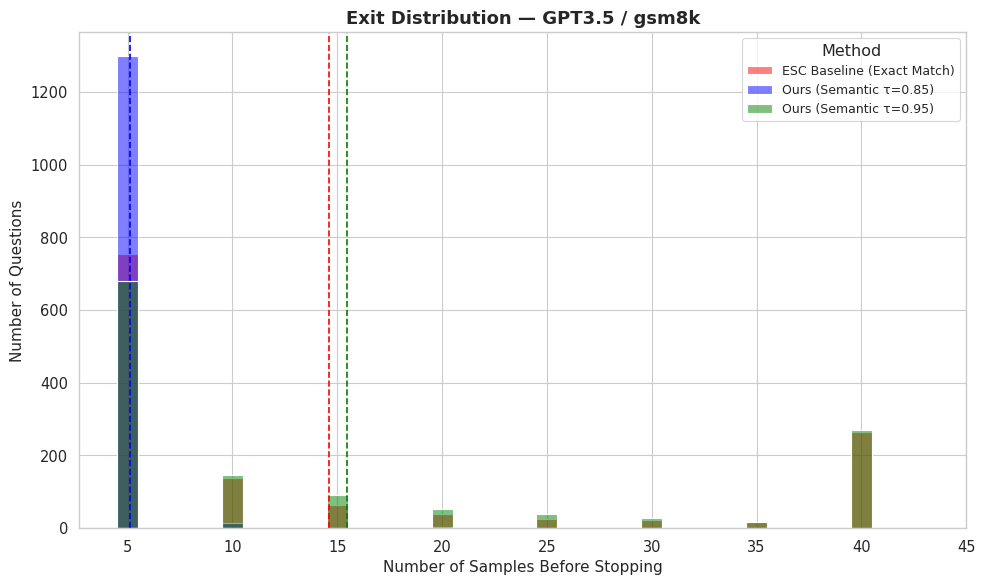

✅ Saved: exit_distribution_GPT3.5_gsm8k.png


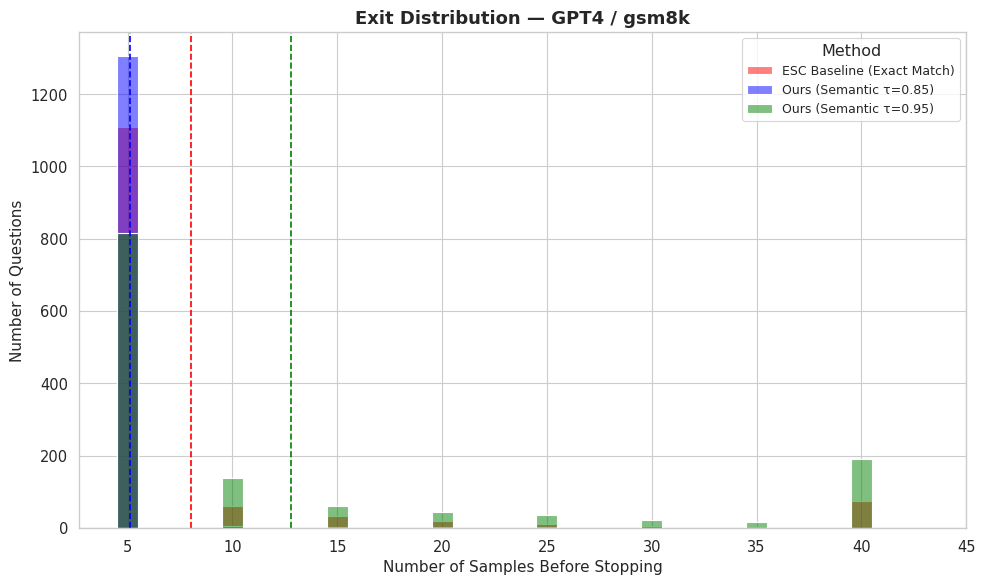

✅ Saved: exit_distribution_GPT4_gsm8k.png


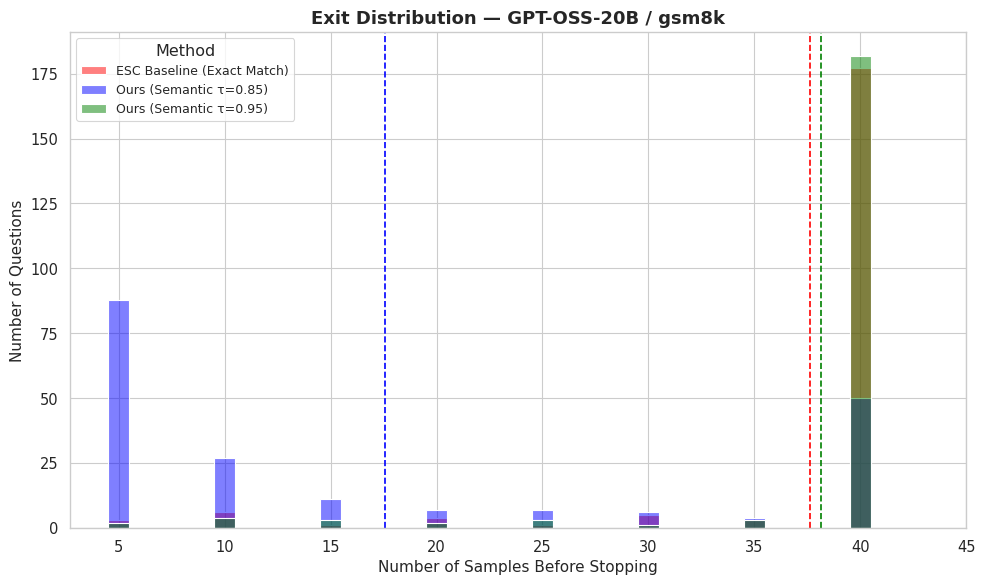

✅ Saved: exit_distribution_GPT-OSS-20B_gsm8k.png


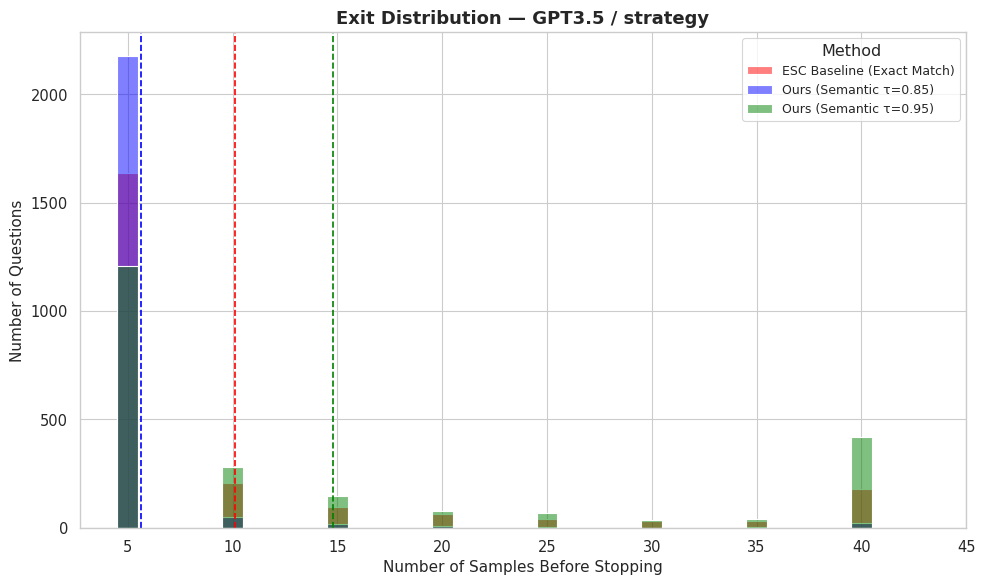

✅ Saved: exit_distribution_GPT3.5_strategy.png


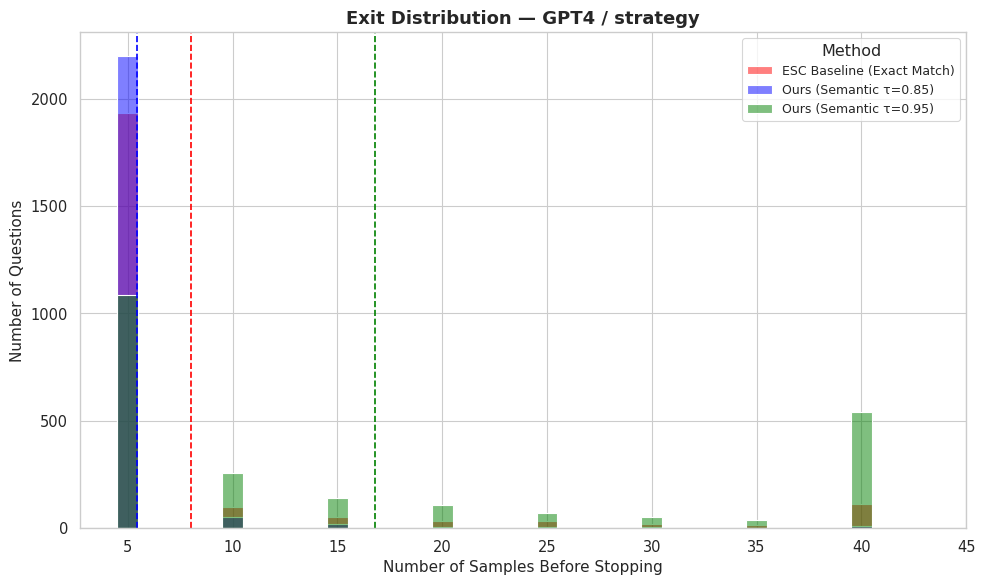

✅ Saved: exit_distribution_GPT4_strategy.png


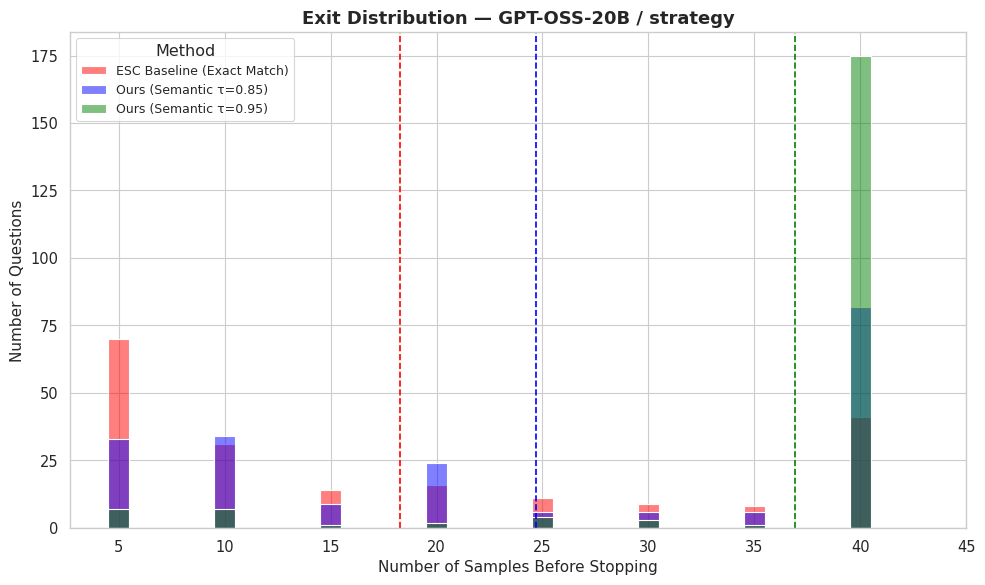

✅ Saved: exit_distribution_GPT-OSS-20B_strategy.png


In [11]:
# Cell 5: Exit Distribution — All Models & Datasets (Separate Figures)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

tasks  = df_results['task_type'].unique()
models = df_results['model_type'].unique()
bins   = range(WINDOW_SIZE, MAX_SAMPLES + WINDOW_SIZE + 1, WINDOW_SIZE)

for task in tasks:
    for model in models:

        df_model = df_results[
            (df_results['model_type'] == model) &
            (df_results['task_type']  == task)
        ]

        if df_model.empty:
            continue

        baseline_exits     = df_model['baseline_stop_window']
        semantic_exits_085 = df_model['stop_window_0.85']
        semantic_exits_095 = df_model['stop_window_0.95']

        fig, ax = plt.subplots(figsize=(10, 6))

        sns.histplot(baseline_exits,     bins=bins, color="red",   alpha=0.5,
                     label="ESC Baseline (Exact Match)", discrete=True, ax=ax)
        sns.histplot(semantic_exits_085, bins=bins, color="blue",  alpha=0.5,
                     label="Ours (Semantic τ=0.85)",     discrete=True, ax=ax)
        sns.histplot(semantic_exits_095, bins=bins, color="green", alpha=0.5,
                     label="Ours (Semantic τ=0.95)",     discrete=True, ax=ax)

        ax.axvline(baseline_exits.mean(),     color="red",   linestyle="--", linewidth=1.2)
        ax.axvline(semantic_exits_085.mean(), color="blue",  linestyle="--", linewidth=1.2)
        ax.axvline(semantic_exits_095.mean(), color="green", linestyle="--", linewidth=1.2)

        ax.set_title(f'Exit Distribution — {model} / {task}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Number of Samples Before Stopping', fontsize=11)
        ax.set_ylabel('Number of Questions', fontsize=11)
        ax.set_xticks(list(bins))
        ax.legend(title="Method", fontsize=9)

        plt.tight_layout()
        plt.savefig(f"exit_distribution_{model}_{task}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: exit_distribution_{model}_{task}.png")

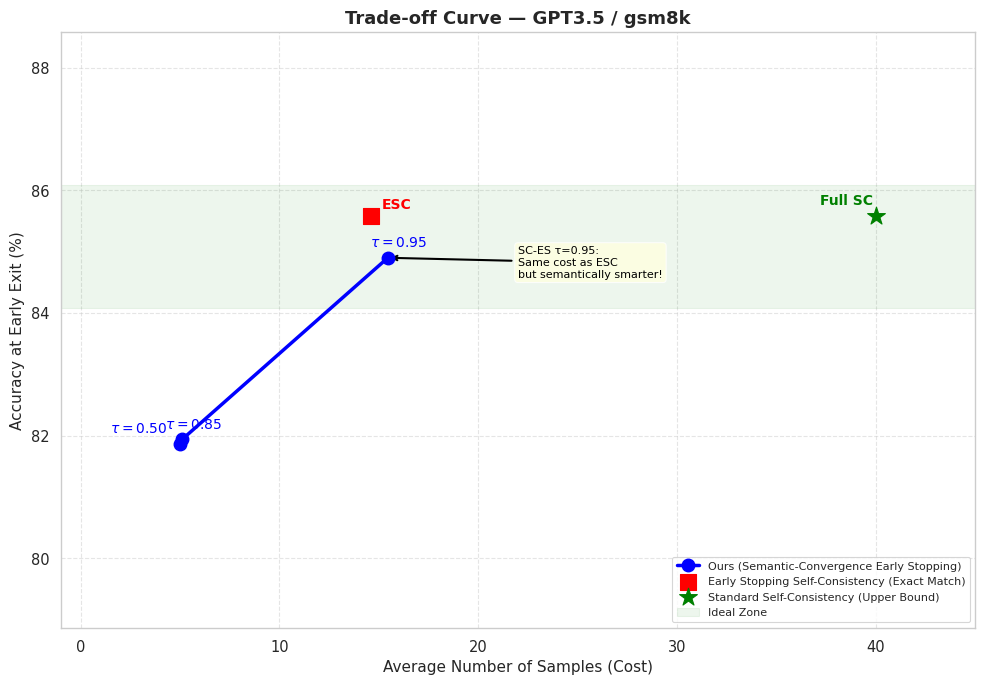

✅ Saved: tradeoff_GPT3.5_gsm8k.png


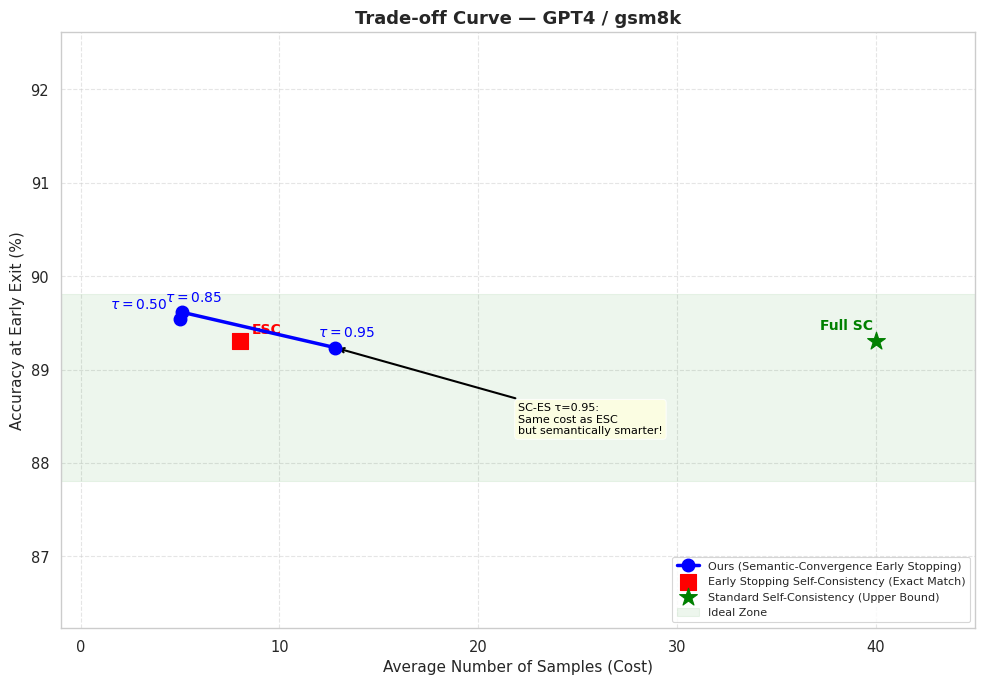

✅ Saved: tradeoff_GPT4_gsm8k.png


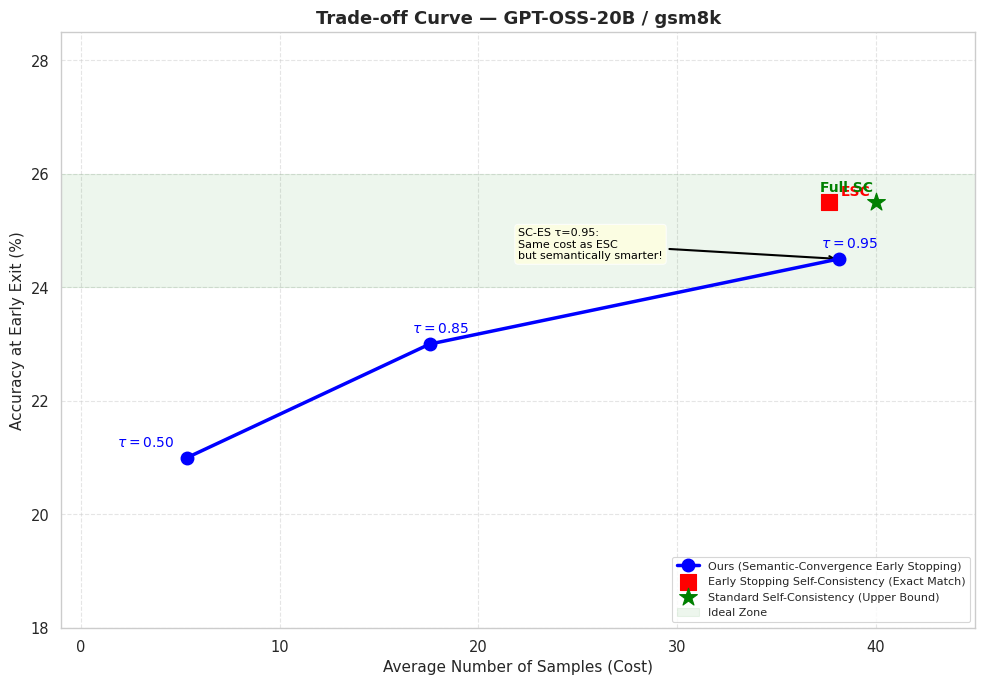

✅ Saved: tradeoff_GPT-OSS-20B_gsm8k.png


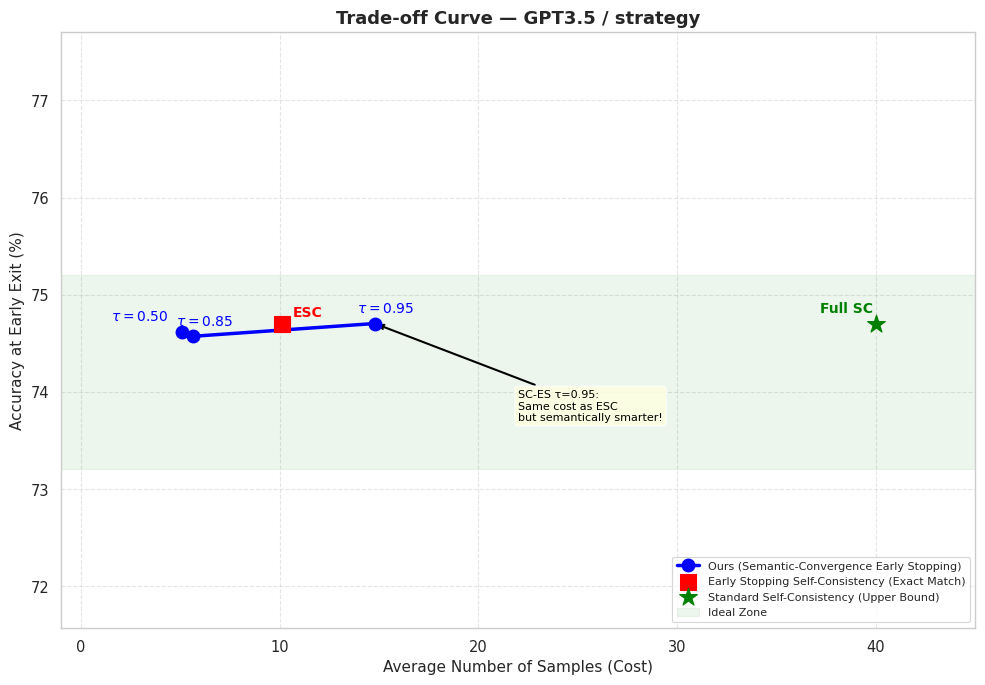

✅ Saved: tradeoff_GPT3.5_strategy.png


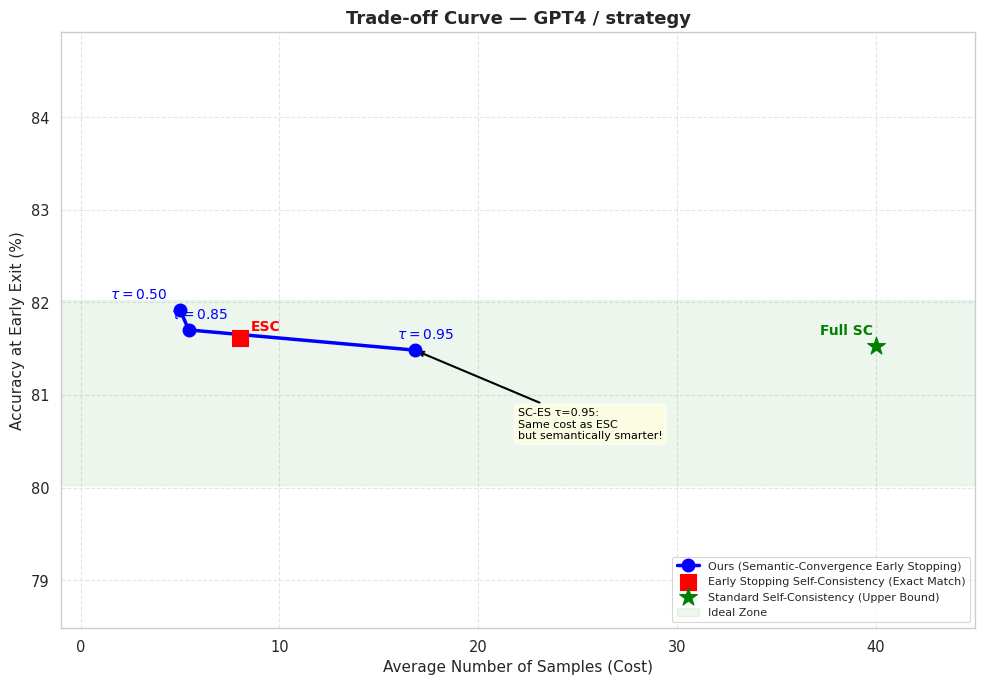

✅ Saved: tradeoff_GPT4_strategy.png


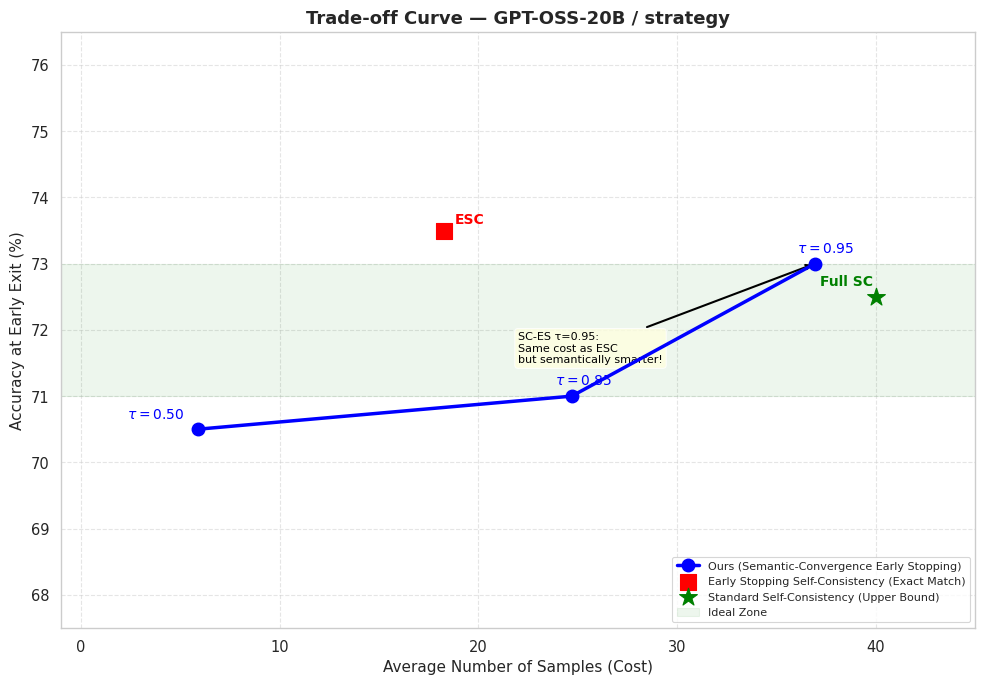

✅ Saved: tradeoff_GPT-OSS-20B_strategy.png

Real Values Used:

  GPT3.5 / gsm8k:
    Full SC     : 85.58%
    ESC         : 85.58%  samples=14.59
    SC-ES τ=0.50: 81.87%  samples=5.00
    SC-ES τ=0.85: 81.94%  samples=5.11
    SC-ES τ=0.95: 84.90%  samples=15.45

  GPT4 / gsm8k:
    Full SC     : 89.31%
    ESC         : 89.31%  samples=8.04
    SC-ES τ=0.50: 89.54%  samples=5.00
    SC-ES τ=0.85: 89.61%  samples=5.09
    SC-ES τ=0.95: 89.23%  samples=12.79

  GPT-OSS-20B / gsm8k:
    Full SC     : 25.50%
    ESC         : 25.50%  samples=37.65
    SC-ES τ=0.50: 21.00%  samples=5.35
    SC-ES τ=0.85: 23.00%  samples=17.55
    SC-ES τ=0.95: 24.50%  samples=38.12

  GPT3.5 / strategy:
    Full SC     : 74.70%
    ESC         : 74.70%  samples=10.12
    SC-ES τ=0.50: 74.62%  samples=5.07
    SC-ES τ=0.85: 74.57%  samples=5.64
    SC-ES τ=0.95: 74.70%  samples=14.79

  GPT4 / strategy:
    Full SC     : 81.53%
    ESC         : 81.62%  samples=8.02
    SC-ES τ=0.50: 81.92%  samples=5.00
 

In [12]:
# Cell 6: Trade-off Curve — All Models & Datasets (Separate Figures)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# ── Compute accuracy automatically ────────────────────────────────────────────
accuracy_data = {}
for model in MODELS_TO_RUN:
    accuracy_data[model] = {}
    for task in TASKS_TO_RUN:
        df_m = df_results[
            (df_results['model_type'] == model) &
            (df_results['task_type']  == task)
        ]
        if df_m.empty:
            continue

        sc_acc  = df_m['is_correct_full'].mean()     * 100
        bl_acc  = df_m['is_correct_baseline'].mean() * 100
        acc_050 = df_m['is_correct_0.50'].mean()     * 100
        acc_085 = df_m['is_correct_0.85'].mean()     * 100
        acc_095 = df_m['is_correct_0.95'].mean()     * 100

        y_min = max(0,   min(sc_acc, bl_acc, acc_050, acc_085, acc_095) - 3)
        y_max = min(100, max(sc_acc, bl_acc, acc_050, acc_085, acc_095) + 3)

        accuracy_data[model][task] = {
            'sc':       sc_acc,
            'baseline': bl_acc,
            'tau_050':  acc_050,
            'tau_085':  acc_085,
            'tau_095':  acc_095,
            'ylim':     (y_min, y_max),
            'ideal':    (sc_acc - 1.5, sc_acc + 0.5),
        }

# ── Separate figure per model/task ────────────────────────────────────────────
for task in TASKS_TO_RUN:
    for model in MODELS_TO_RUN:

        if task not in accuracy_data.get(model, {}):
            continue

        acc  = accuracy_data[model][task]
        df_m = df_results[
            (df_results['model_type'] == model) &
            (df_results['task_type']  == task)
        ]

        if df_m.empty:
            continue

        avg_bl  = df_m['baseline_stop_window'].mean()
        avg_050 = df_m['stop_window_0.50'].mean()
        avg_085 = df_m['stop_window_0.85'].mean()
        avg_095 = df_m['stop_window_0.95'].mean()
        avg_sc  = MAX_SAMPLES

        methods_x = [avg_050,        avg_085,        avg_095]
        methods_y = [acc['tau_050'], acc['tau_085'], acc['tau_095']]
        labels    = [r'$\tau=0.50$', r'$\tau=0.85$', r'$\tau=0.95$']

        fig, ax = plt.subplots(figsize=(10, 7))

        ax.plot(methods_x, methods_y,
                marker='o', markersize=9, linestyle='-', linewidth=2.5,
                color='blue', label='Ours (Semantic-Convergence Early Stopping)',
                zorder=4)

        for i, txt in enumerate(labels):
            offset = (-30, 8) if i == 0 else (8, 8)
            ax.annotate(txt, (methods_x[i], methods_y[i]),
                        textcoords="offset points", xytext=offset,
                        ha='center', color='blue', fontweight='bold', fontsize=10)

        ax.scatter([avg_bl], [acc['baseline']],
                   color='red', s=120, marker='s',
                   label='Early Stopping Self-Consistency (Exact Match)',
                   zorder=5)
        ax.annotate('ESC', (avg_bl, acc['baseline']),
                    textcoords="offset points", xytext=(8, 5),
                    color='red', fontweight='bold', fontsize=10)

        ax.scatter([avg_sc], [acc['sc']],
                   color='green', s=180, marker='*',
                   label='Standard Self-Consistency (Upper Bound)',
                   zorder=5)
        ax.annotate('Full SC', (avg_sc, acc['sc']),
                    textcoords="offset points", xytext=(-40, 8),
                    color='green', fontweight='bold', fontsize=10)

        ax.axhspan(acc['ideal'][0], acc['ideal'][1],
                   alpha=0.07, color='green', label='Ideal Zone')

        ax.annotate(
            'SC-ES τ=0.95:\nSame cost as ESC\nbut semantically smarter!',
            xy=(avg_095, acc['tau_095']),
            xytext=(22, acc['ideal'][0] + 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=8, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
        )

        ax.set_title(f'Trade-off Curve — {model} / {task}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Average Number of Samples (Cost)', fontsize=11)
        ax.set_ylabel('Accuracy at Early Exit (%)', fontsize=11)
        ax.set_xlim(-1, 45)
        ax.set_ylim(acc['ylim'])
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.savefig(f"tradeoff_{model}_{task}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: tradeoff_{model}_{task}.png")

# ── Print values ──────────────────────────────────────────────────────────────
print("\nReal Values Used:")
for task in TASKS_TO_RUN:
    for model in MODELS_TO_RUN:
        if task not in accuracy_data.get(model, {}):
            continue
        acc  = accuracy_data[model][task]
        df_m = df_results[
            (df_results['model_type'] == model) &
            (df_results['task_type']  == task)
        ]
        print(f"\n  {model} / {task}:")
        print(f"    Full SC     : {acc['sc']:.2f}%")
        print(f"    ESC         : {acc['baseline']:.2f}%  samples={df_m['baseline_stop_window'].mean():.2f}")
        print(f"    SC-ES τ=0.50: {acc['tau_050']:.2f}%  samples={df_m['stop_window_0.50'].mean():.2f}")
        print(f"    SC-ES τ=0.85: {acc['tau_085']:.2f}%  samples={df_m['stop_window_0.85'].mean():.2f}")
        print(f"    SC-ES τ=0.95: {acc['tau_095']:.2f}%  samples={df_m['stop_window_0.95'].mean():.2f}")

In [13]:
#Accuracy Table
import pandas as pd

# 1. Convert the existing simulation results to a DataFrame
if 'simulation_results' in locals() and len(simulation_results) > 0:
    df_res = pd.DataFrame(simulation_results)

    accuracy_summary = []

    # 2. Group results by Model and Dataset Task
    grouped = df_res.groupby(['model_type', 'task_type'])
    for (model, task), df_group in grouped:
        accuracy_summary.append({
            'Model': model,
            'Task/Dataset': task,
            'Standard SC (No Early Stop) (%)': round(df_group['is_correct_full'].mean() * 100, 2),
            'ESC Baseline (%)': round(df_group['is_correct_baseline'].mean() * 100, 2),
            'Ours (τ=0.50) (%)': round(df_group['is_correct_0.50'].mean() * 100, 2),
            'Ours (τ=0.85) (%)': round(df_group['is_correct_0.85'].mean() * 100, 2),
            'Ours (τ=0.95) (%)': round(df_group['is_correct_0.95'].mean() * 100, 2)
        })

    df_accuracy_table = pd.DataFrame(accuracy_summary)

    # 3. Print out plain text format
    print("\n" + "="*40)
    print("      CONSOLIDATED ACCURACY TABLE FOR JOURNAL")
    print("="*40)
    print(df_accuracy_table.to_string(index=False))

    # 4. Display interactive visual table inside Colab
    try:
        from IPython.display import display
        print("\nFormatted Colab View (Green indicates highest accuracy per row):")
        display(df_accuracy_table.style.highlight_max(axis=1, subset=df_accuracy_table.columns[2:], color='lightgreen'))
    except Exception:
        pass
else:
    print("Error: 'simulation_results' was not found in your environment. Please ensure you run Cell 3 completely before running this cell.")


      CONSOLIDATED ACCURACY TABLE FOR JOURNAL
      Model Task/Dataset  Standard SC (No Early Stop) (%)  ESC Baseline (%)  Ours (τ=0.50) (%)  Ours (τ=0.85) (%)  Ours (τ=0.95) (%)
GPT-OSS-20B        gsm8k                            25.50             25.50              21.00              23.00              24.50
GPT-OSS-20B     strategy                            72.50             73.50              70.50              71.00              73.00
     GPT3.5        gsm8k                            85.58             85.58              81.87              81.94              84.90
     GPT3.5     strategy                            74.70             74.70              74.62              74.57              74.70
       GPT4        gsm8k                            89.31             89.31              89.54              89.61              89.23
       GPT4     strategy                            81.53             81.62              81.92              81.70              81.48

Formatted Colab View 

,Model,Task/Dataset,Standard SC (No Early Stop) (%),ESC Baseline (%),Ours (τ=0.50) (%),Ours (τ=0.85) (%),Ours (τ=0.95) (%)
0,GPT-OSS-20B,gsm8k,25.500000,25.500000,21.000000,23.000000,24.500000
1,GPT-OSS-20B,strategy,72.500000,73.500000,70.500000,71.000000,73.000000
2,GPT3.5,gsm8k,85.580000,85.580000,81.870000,81.940000,84.900000
3,GPT3.5,strategy,74.700000,74.700000,74.620000,74.570000,74.700000
4,GPT4,gsm8k,89.310000,89.310000,89.540000,89.610000,89.230000
5,GPT4,strategy,81.530000,81.620000,81.920000,81.700000,81.480000


In [14]:
# Download all figures from Colab

import os
import zipfile
from google.colab import files

# Create zip file with all PNG figures
zip_path = "/content/all_figures.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for f in os.listdir("/content/ESC"):
        if f.endswith(".png"):
            zipf.write(f"/content/ESC/{f}", f)
            print(f"Added: {f}")

print(f"\n✅ Zip created!")
files.download(zip_path)

Added: exit_distribution_GPT3.5_gsm8k.png
Added: img.png
Added: tradeoff_GPT-OSS-20B_gsm8k.png
Added: tradeoff_GPT4_strategy.png
Added: tradeoff_GPT4_gsm8k.png
Added: tradeoff_GPT3.5_gsm8k.png
Added: exit_distribution_GPT4_strategy.png
Added: exit_distribution_GPT3.5_strategy.png
Added: exit_distribution_GPT-OSS-20B_gsm8k.png
Added: tradeoff_GPT-OSS-20B_strategy.png
Added: exit_distribution_GPT-OSS-20B_strategy.png
Added: tradeoff_GPT3.5_strategy.png
Added: exit_distribution_GPT4_gsm8k.png

✅ Zip created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>